### Tissera Ana Paula - `Notebook TP4`

In [1]:
%load_ext autoreload
%autoreload 2

##### Imports

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os
import pandas as pd

In [3]:
# uso de cupy en vez de numpy para correrlo en GPU
import cupy as cp

device_id = cp.cuda.Device().id
device_name = cp.cuda.runtime.getDeviceProperties(device_id)['name']

print(f"Usando GPU {device_id}: {device_name}")

Usando GPU 0: b'NVIDIA GeForce RTX 3050 Laptop GPU'


In [4]:
SEED = 42

## `1.` **Clustering de datos**

##### Cargar los datos

In [14]:
clustering_path = "data/clustering.csv"
clustering_df = pd.read_csv(clustering_path)

##### Visualización de ejemplo

In [8]:
clustering_df.sample(5, random_state=SEED)

,Unnamed: 0,A,B
84,84,822368,648690
2470,2470,954037,754046
2804,2804,640123,716370
4987,4987,772586,123935
4924,4924,598444,128607


### `a.` **K-Means** con ganancias decrecientes para determinar K

In [15]:
from src.models import kmeans

In [17]:

X = clustering_df.values  # asume que el CSV solo contiene las dos columnas de coordenadas



##### $L$ vs. $K$

K =  1  →  L = 1510492256.44
K =  2  →  L = 1110294179.03
K =  3  →  L = 888186353.24
K =  4  →  L = 738612512.87
K =  5  →  L = 660608805.06
K =  6  →  L = 595493194.20
K =  7  →  L = 557439709.45
K =  8  →  L = 530801270.62
K =  9  →  L = 445348897.64
K = 10  →  L = 399846632.30


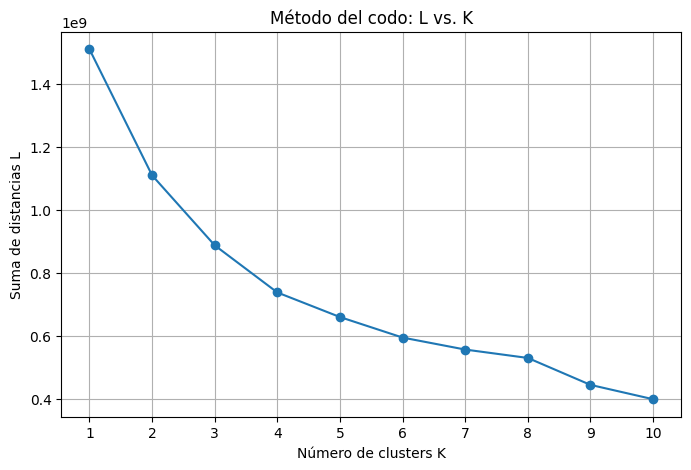

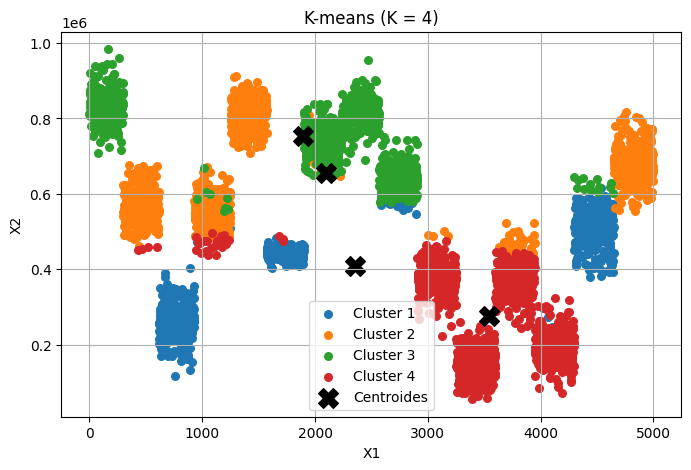

In [ ]:
# --- Método de ganancias decrecientes: calcular L vs. K ---
Ks = range(1, 50)
Ls = []
for K in Ks:
    _, _, L = kmeans(X, K)
    Ls.append(L)
    print(f"K = {K:2d}  →  L = {L:.2f}")

# Graficar L vs. K (elbow plot)
plt.figure(figsize=(8,5))
plt.plot(Ks, Ls, marker='o')
plt.xlabel("Número de clusters K")
plt.ylabel("Suma de distancias L")
plt.title("Método del codo: L vs. K")
plt.xticks(Ks)
plt.grid(True)
plt.show()

# --- Elegir K óptimo tras inspeccionar el gráfico ---
K_opt = 4  # Ajusta este valor según tu gráfico

# Ejecutar K-means con K óptimo y graficar clusters resultantes
labels_opt, centroids_opt, _ = kmeans(X, K_opt)

plt.figure(figsize=(8,5))
for k in range(K_opt):
    pts = X[labels_opt == k]
    plt.scatter(pts[:,0], pts[:,1], s=30, label=f"Cluster {k+1}")
plt.scatter(centroids_opt[:,0], centroids_opt[:,1],
            marker='X', s=200, c='black', label="Centroides")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title(f"K-means (K = {K_opt})")
plt.legend()
plt.grid(True)
plt.show()

##### Gráfico del conjunto $x_i$

### `b.`  Gaussian Mixture Model (**GMM**)

##### inicialización de GMM con una corrida de K-means

### `c.`  **DBSCAN**

##### Variación de los parámetros ε (radio de la vecindad) y $K$ (mínimo número de puntos en una zona densa)

##### Elección de una combinación de ε y K

##### Gráfico de los datos

## `2.` **Reducción de dimensionalidad**

##### Cargar los datos


In [11]:
MNIST_path = "data/MNIST_dataset.csv"
MNIST_df = pd.read_csv(MNIST_path)

##### Visualización de ejemplo  

In [13]:
MNIST_df.sample(5, random_state=SEED)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
46730,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
48393,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41416,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
34506,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
43725,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### `a.` **PCA**

##### Gráfico de cómo varía el error cuadrático medio de reconstrucción sobre el conjunto de datos en función de la cantidad de componentes principales utilizadas

### `b.` Selección de **componentes principales**

##### Gráfico de las imagenes de los digitos originales y reconstruidos para las primeras 10 muestras del dataset con ... cantidad de componentes

### `c.` Modelo de Autoencoder Variacional (**VAE**) usando PyTorch

##### División en entrenamiento y validación

##### Entrenamiento

##### Comparación con PCA